# Exercise 3: Regional connection

Tasks 
* Task 1

In [70]:
import pypsa
pypsa.options.api.new_components_api = True

n = pypsa.Network('exercise_2.xlsx')




INFO:pypsa.network.io:Imported network 'pypsa_model' has buses, carriers, generators, global_constraints, lines, line_types, links, loads, processes, shapes, shunt_impedances, storage_units, stores, sub_networks, transformers, transformer_types


In [71]:
n.sanitize()

INFO:pypsa.consistency:Sanitizing network...
INFO:pypsa.components._types.carriers:Assigned colors to 8 carriers using 'tab10' palette.
INFO:pypsa.consistency:Network sanitization complete.


In [72]:
n.optimize()

C:\Users\USER\AppData\Local\Temp\ipykernel_14888\1261279110.py:1: FutureWarning: The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.
  n.optimize()
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 8/8 [00:00<00:00, 313.17it/s]
INFO:linopy.io: Writing time: 0.21s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 210253 primals, 473052 duals
Objective: 2.89e+08
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper, Link-fix-p-lower, Link-fix-p-upper, StorageUnit-ext-p_dispatch-lower, Stor

('ok', 'optimal')

<Axes: ylabel='name'>

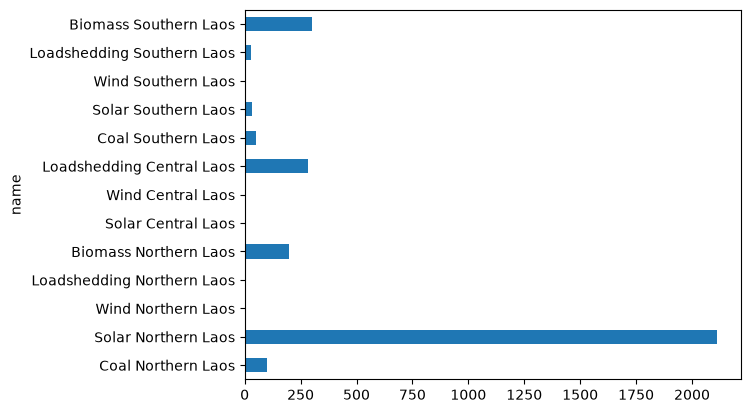

In [73]:
n.generators.static.p_nom_opt.plot.barh()

<Axes: ylabel='name'>

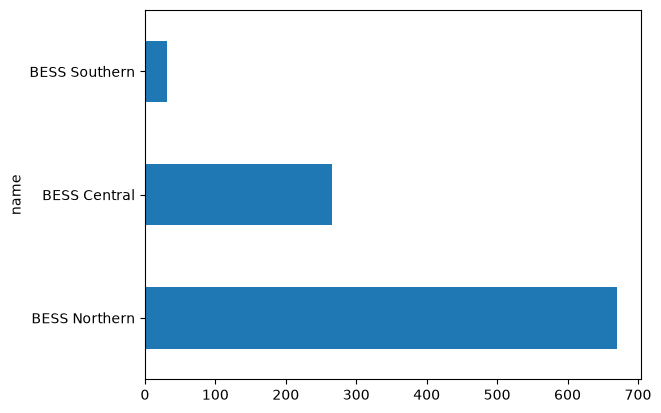

In [74]:
n.storage_units.static.p_nom_opt.plot.barh()

<Axes: xlabel='snapshot'>

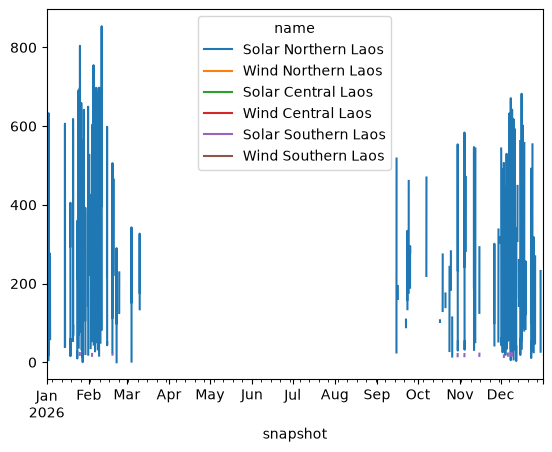

In [78]:
s = n.statistics

df = s.curtailment(groupby = False, groupby_time = False, carrier = ['solar','wind']).T

df.columns = df.columns.get_level_values("name")

df.plot()

In [81]:
s.curtailment(groupby = False, carrier = ['solar','wind'])


component  name               
Generator  Solar Northern Laos    80858.98519
           Solar Southern Laos     1059.48835
dtype: float64